# Damped Harmonic Motion

This notebook examines a model of a suspension mechanism, using the equation for damped harmonic motion, written in standard engineering notation.

In [1]:
using Plots

In [2]:
using SymPy

### 1. defining the ordinary differential equation

The differential equation for damped harmonic motion is

$$
   \frac{d^2}{d~\!t^2} y(t) + 2 \zeta \omega \frac{d}{d~\!t} y(t) + \omega^2 y(t) = 0.
$$

In [3]:
t, omega, zeta = Sym("t, omega, zeta")

(t, omega, zeta)

In [4]:
y = SymFunction("y")

y

In [5]:
ode = Eq(diff(y(t),t,2), - 2*zeta*omega*diff(y(t),t) - omega^2*y(t))

  2                                              
 d                 2                     d       
---(y(t)) = - omega *y(t) - 2*omega*zeta*--(y(t))
  2                                      dt      
dt                                               

In [6]:
sol = dsolve(ode)

                   /           ___________\                /          ________
                   |          /     2     |                |         /     2  
           omega*t*\-zeta + \/  zeta  - 1 /       -omega*t*\zeta + \/  zeta  -
y(t) = C1*e                                 + C2*e                            

___\
   |
 1 /
    

Let us provide initial conditions:

* initial displacement is at 1: y(0) = 1

* initial velocity is zero: y'(0) = 0.

In [7]:
dy = diff(y(t),t)

d       
--(y(t))
dt      

In [8]:
dy0 = subs(dy,t=>0)

/d       \|   
|--(y(t))||   
\dt      /|t=0

In [9]:
initconds = Dict(y(0)=>1, dy0=>0)

Dict{Sym{PyCall.PyObject}, Int64} with 2 entries:
  Subs(Derivative(y(t), t), t, 0) => 0
  y(0)                            => 1

In [10]:
sol0 = dsolve(ode, ics=initconds)

                                          /          ___________\             
                                          |         /     2     |             
       /        zeta         1\  -omega*t*\zeta + \/  zeta  - 1 /   /      zet
y(t) = |- ---------------- + -|*e                                 + |---------
       |       ___________   2|                                     |     ____
       |      /     2         |                                     |    /    
       \  2*\/  zeta  - 1     /                                     \2*\/  zet

                      /           ___________\
                      |          /     2     |
a         1\  omega*t*\-zeta + \/  zeta  - 1 /
------- + -|*e                                
_______   2|                                  
 2         |                                  
a  - 1     /                                  

Consider the general form of the solution, we observe that $\zeta^2 - 1$ is a discriminant.

### 2. The First Case: zeta < 1

In [11]:
ode1 = subs(ode, zeta=>1/2, omega=>1)

  2                         
 d                  d       
---(y(t)) = -y(t) - --(y(t))
  2                 dt      
dt                          

In [12]:
sol1 = dsolve(ode1, ics=initconds)

       /         /  ___  \               \     
       |  ___    |\/ 3 *t|               |  -t 
       |\/ 3 *sin|-------|      /  ___  \|  ---
       |         \   2   /      |\/ 3 *t||   2 
y(t) = |------------------ + cos|-------||*e   
       \        3               \   2   //     

To plot the solution, make a function of the right hand side.

In [13]:
sol1fun(x) = subs(sol1.rhs(), t=>x)

sol1fun (generic function with 1 method)

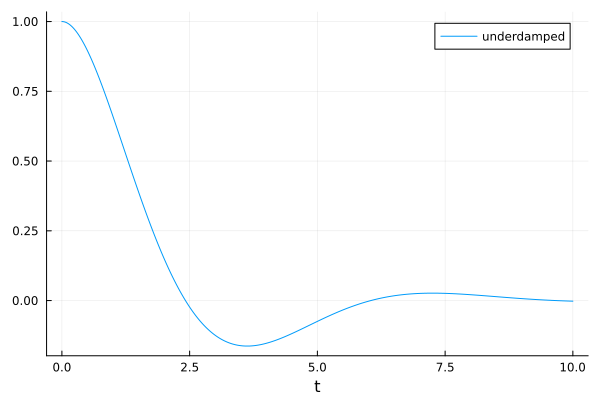

In [14]:
plot(0:0.01:10, sol1fun, xlabel="t", label="underdamped")

In [15]:
# savefig("figdampedunder.png")

### 3. The Second Case: zeta = 1

When $\zeta = 1$, the characteristic equation has one double root.

In [16]:
ode2 = subs(ode, zeta=>1, omega=>1)

  2                           
 d                    d       
---(y(t)) = -y(t) - 2*--(y(t))
  2                   dt      
dt                            

In [17]:
sol2 = dsolve(ode2, ics=initconds)

                -t
y(t) = (t + 1)*e  

In [18]:
sol2fun(x) = subs(sol2.rhs(), t=>x)

sol2fun (generic function with 1 method)

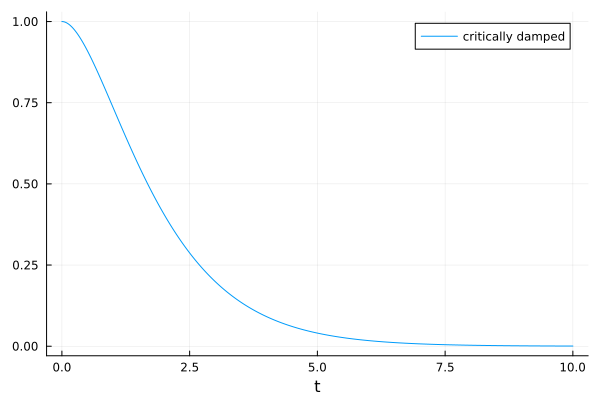

In [19]:
plot(0:0.01:10, sol2fun, xlabel="t", label="critically damped")

In [20]:
# savefig("figdampedcritical.png")

### 4. The Third Case: zeta > 1

In [21]:
ode3 = subs(ode, zeta=>3/2, omega=>1)

  2                             
 d                      d       
---(y(t)) = -y(t) - 3.0*--(y(t))
  2                     dt      
dt                              

In [22]:
sol3 = dsolve(ode3, ics=initconds)

                            -2.61803398874989*t                     -0.3819660
y(t) = - 0.170820393249937*e                    + 1.17082039324994*e          

11250105*t
          

In [23]:
sol3fun(x) = subs(sol3.rhs(), t=>x)

sol3fun (generic function with 1 method)

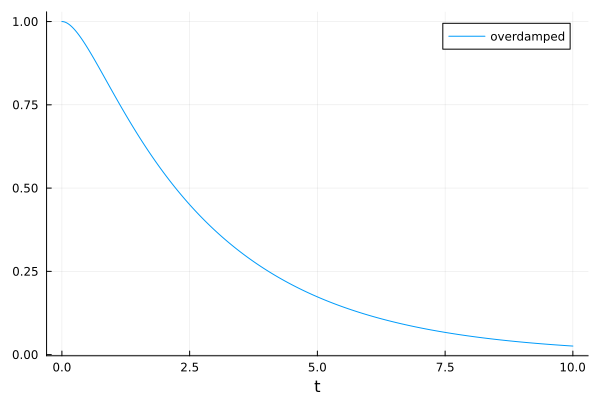

In [24]:
plot(0:0.01:10, sol3fun, xlabel="t", label="overdamped")

In [25]:
# savefig("figdampedover.png")

### the role of omega

Let us set the value of $\omega$ to two and look for $\zeta = 1$.

In [26]:
ode4 = subs(ode, omega=>2, zeta=>1)

  2                             
 d                      d       
---(y(t)) = -4*y(t) - 4*--(y(t))
  2                     dt      
dt                              

In [27]:
sol4 = dsolve(ode4, ics=initconds)

                  -2*t
y(t) = (2*t + 1)*e    

In [28]:
sol4fun(x) = subs(sol4.rhs(), t=>x)

sol4fun (generic function with 1 method)

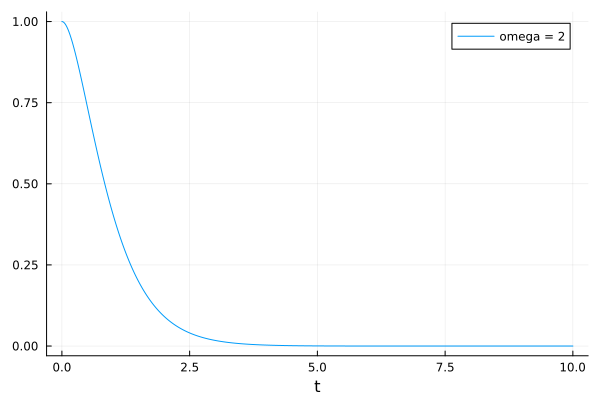

In [29]:
plot(0:0.01:10, sol4fun, xlabel="t", label="omega = 2")

In [30]:
# savefig("figdampedomega2.png")

The value of $\omega$ determines how fast the deviation disappears.